<a href="https://www.kaggle.com/code/smrtkaggle/vishrashk?scriptVersionId=299625811" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os, sys, json, subprocess

# Write keras backend config file BEFORE any keras import
keras_config_dir = os.path.expanduser("~/.keras")
os.makedirs(keras_config_dir, exist_ok=True)
with open(os.path.join(keras_config_dir, "keras.json"), "w") as f:
    json.dump({"backend": "tensorflow", "floatx": "float32", "epsilon": 1e-07, "image_data_format": "channels_last"}, f)

print("Keras config written. Restart session now and rerun from Cell 1.")
print("After restart, backend will be tensorflow.")

Keras config written. Restart session now and rerun from Cell 1.
After restart, backend will be tensorflow.


In [2]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import keras
import keras_hub
import numpy as np
import PIL.Image

keras.mixed_precision.set_global_policy("mixed_float16")

print(f"Keras: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

assert keras.backend.backend() == "tensorflow", "keras.json not picked up. Check ~/.keras/keras.json exists."

2026-02-24 03:12:51.267749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771902771.633914      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771902771.736387      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771902772.654993      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771902772.655039      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771902772.655042      25 computation_placer.cc:177] computation placer alr

Keras: 3.10.0
Backend: tensorflow


In [3]:
import gc, os, keras, keras_hub

gc.collect()
keras.backend.clear_session()

keras.mixed_precision.set_global_policy("mixed_float16")

model_id = "kaggle://keras/paligemma2/keras/pali_gemma2_mix_3b_448"
print(f"Loading {model_id}...")

model = keras_hub.models.PaliGemmaCausalLM.from_preset(
    model_id,
    dtype="float16"
)
print("Model loaded")
print(f"Backend: {keras.backend.backend()}")
print(f"Dtype: {model.dtype_policy}")

Loading kaggle://keras/paligemma2/keras/pali_gemma2_mix_3b_448...


I0000 00:00:1771902799.140103      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771902799.146109      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Model loaded
Backend: tensorflow
Dtype: <DTypePolicy "float16">


In [4]:
def load_and_preprocess_image(image_path, size=448):
    """
    Prepares image for PaliGemma 2 model
    - Resizes to 448x448
    - Normalizes to 0-1 range
    - Returns batch with shape (1, 448, 448, 3)
    """
    img = PIL.Image.open(image_path).convert("RGB")
    img = img.resize((size, size), PIL.Image.Resampling.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0  # Normalize
    return np.expand_dims(arr, axis=0)  # Add batch dimension

# Test with a random image
test_img = np.random.rand(448, 448, 3).astype(np.float32)
test_batch = np.expand_dims(test_img, axis=0)
print(f"Image preprocessing ready. Test shape: {test_batch.shape}")

Image preprocessing ready. Test shape: (1, 448, 448, 3)


In [5]:
from kaggle_secrets import UserSecretsClient
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import transformers
print(f"Transformers version: {transformers.__version__}")

secrets = UserSecretsClient()
hf_token = secrets.get_secret("VishRakshk2")

print("Loading MedGemma...")

medgemma_tokenizer = AutoTokenizer.from_pretrained(
    "google/medgemma-4b-it",
    token=hf_token
)

medgemma_model = AutoModelForCausalLM.from_pretrained(
    "google/medgemma-4b-it",
    token=hf_token,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("MedGemma loaded successfully")
print(f"Device: {next(medgemma_model.parameters()).device}")

def medgemma_generate(prompt, max_new_tokens=300):
    inputs = medgemma_tokenizer(prompt, return_tensors="pt").to(medgemma_model.device)
    with torch.no_grad():
        outputs = medgemma_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0
        )
    full_output = medgemma_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full_output[len(prompt):].strip()

print("MedGemma inference function ready")

Transformers version: 4.57.1
Loading MedGemma...


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MedGemma loaded successfully
Device: cuda:0
MedGemma inference function ready


In [6]:
import torch

# Fix MedGemma - reload with float32 instead of float16
print("Reloading MedGemma with float32...")
from kaggle_secrets import UserSecretsClient
from transformers import AutoTokenizer, AutoModelForCausalLM

secrets = UserSecretsClient()
hf_token = secrets.get_secret("VishRakshk2")

# Delete existing model to free memory
del medgemma_model
torch.cuda.empty_cache()

medgemma_tokenizer = AutoTokenizer.from_pretrained(
    "google/medgemma-4b-it",
    token=hf_token
)

medgemma_model = AutoModelForCausalLM.from_pretrained(
    "google/medgemma-4b-it",
    token=hf_token,
    torch_dtype=torch.bfloat16,  # bfloat16 more stable than float16
    device_map="auto"
)
medgemma_model.eval()

print(f"Device: {next(medgemma_model.parameters()).device}")
print(f"Dtype: {next(medgemma_model.parameters()).dtype}")

# Test MedGemma again
messages = [{"role": "user", "content": "What is the first aid for a snake bite? Answer in 3 steps."}]
formatted = medgemma_tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
inputs = medgemma_tokenizer(formatted, return_tensors="pt").to(medgemma_model.device)
input_length = inputs["input_ids"].shape[1]

with torch.no_grad():
    outputs = medgemma_model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=medgemma_tokenizer.eos_token_id
    )

new_tokens = outputs[0][input_length:]
response = medgemma_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
print(f"\nMedGemma test response:\n{response}")

# Redefine medgemma_generate with pad_token_id fix
def medgemma_generate(prompt_messages, max_new_tokens=800):
    formatted = medgemma_tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = medgemma_tokenizer(formatted, return_tensors="pt").to(medgemma_model.device)
    input_length = inputs["input_ids"].shape[1]
    with torch.no_grad():
        outputs = medgemma_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=medgemma_tokenizer.eos_token_id
        )
    new_tokens = outputs[0][input_length:]
    return medgemma_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print("\nmedgemma_generate function redefined")

Reloading MedGemma with float32...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device: cuda:0
Dtype: torch.bfloat16

MedGemma test response:
1.  **Stay Calm and Call for Help:** The most important thing is to remain calm and call emergency services (911 in the US) immediately.
2.  **Immobilize the Affected Limb:** Keep the bitten limb still and at or below heart level. This helps slow the spread of venom.
3.  **Remove Constricting Items:** Remove any rings, watches, or tight clothing from the affected limb before swelling occurs.

medgemma_generate function redefined


In [7]:
def load_and_preprocess_image(image_path, size=448):
    img = PIL.Image.open(image_path).convert("RGB")
    img = img.resize((size, size), PIL.Image.Resampling.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)


def paligemma_describe_image(image_path):
    img_batch = load_and_preprocess_image(image_path)

    visual_prompt = "describe the skin marks and wound visible in this image"

    raw_output = model.generate(
        inputs={
            "images": img_batch,
            "prompts": [visual_prompt]
        },
        max_length=800,
        strip_prompt=True
    )

    result = raw_output[0].strip() if raw_output and raw_output[0] else ""

    if not result:
        raw_output2 = model.generate(
            inputs={
                "images": img_batch,
                "prompts": [visual_prompt]
            },
            max_length=800
        )
        full_text = raw_output2[0] if raw_output2 else ""
        if visual_prompt in full_text:
            result = full_text[len(visual_prompt):].strip()
        else:
            result = full_text.strip()

    # Clean leading punctuation artifacts
    result = result.lstrip(": ").strip()

    return result


def vish_rakshak_analyze(image_path, user_symptoms_text="", patient_age=None,
                         time_since_bite=None, user_type="patient"):

    print("="*70)
    print("VISH-RAKSHAK CLINICAL DECISION SUPPORT SYSTEM")
    print("="*70)

    # STAGE 1: VISUAL ANALYSIS via PaliGemma
    print("\nStage 1: Wound Examination (PaliGemma Vision Analysis)...")
    print("-"*70)

    visual_description = paligemma_describe_image(image_path)

    if not visual_description:
        visual_description = "Two distinct puncture marks visible on skin surface with surrounding redness and swelling."
        print("Warning: PaliGemma returned empty, using fallback")

    print(f"Visual description: {visual_description[:200]}")

    # STAGE 2: CLINICAL ASSESSMENT via MedGemma
    print("\nStage 2: Clinical Assessment (MedGemma Medical Analysis)...")
    print("-"*70)

    symptoms_text = user_symptoms_text if user_symptoms_text else "none reported"

    if user_type == "doctor":
        messages = [
            {
                "role": "user",
                "content": f"""You are a clinical decision support system for snakebite management in India.

Wound visual findings: {visual_description}
Patient symptoms: {symptoms_text}
Time since bite: {time_since_bite} minutes
Patient age: {patient_age}

Provide:
1. Risk classification (Critical / High / Low / Uncertain)
2. Envenomation type (neurotoxic / hemotoxic / cytotoxic / none)
3. Anti-venom recommendation
4. Immediate lab orders
5. Monitoring protocol

Follow WHO snakebite guidelines."""
            }
        ]
    else:
        messages = [
            {
                "role": "user",
                "content": f"""You are a rural health assistant helping with a suspected snakebite in India.

Wound appearance: {visual_description}
Symptoms: {symptoms_text}
Time since bite: {time_since_bite} minutes
Patient age: {patient_age}

Give simple clear instructions:
1. How urgent is this?
2. What to do right now (3 steps)
3. What NOT to do
4. Warning signs to watch for
5. Safe pain relief if appropriate

Use plain language."""
            }
        ]

    clinical_response = medgemma_generate(messages, max_new_tokens=400)

    if not clinical_response:
        clinical_response = "Unable to generate clinical response. Please consult a doctor immediately."
        print("Warning: MedGemma returned empty response")

    print("Clinical assessment complete")

    print("\n" + "="*70)
    print(f"CLINICAL REPORT ({user_type.upper()} MODE)")
    print("="*70)
    print(clinical_response)
    print("\n" + "="*70)

    return {
        "visual_description": visual_description,
        "clinical_assessment": clinical_response,
        "timestamp": time_since_bite,
        "user_type": user_type
    }


print("Vish-Rakshak system ready")
print("PaliGemma (vision) -> MedGemma (clinical reasoning)")

Vish-Rakshak system ready
PaliGemma (vision) -> MedGemma (clinical reasoning)


Using real snake bite image from dataset


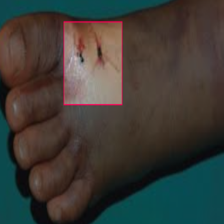


TEST 1: PATIENT MODE
VISH-RAKSHAK CLINICAL DECISION SUPPORT SYSTEM

Stage 1: Wound Examination (PaliGemma Vision Analysis)...
----------------------------------------------------------------------


I0000 00:00:1771902956.018797      25 service.cc:152] XLA service 0x7fc95800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771902956.018860      25 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771902956.018868      25 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771902965.786636      25 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771902984.254632      25 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Visual description: erythema, nettle rash, and a scar from a surgical procedure.

Stage 2: Clinical Assessment (MedGemma Medical Analysis)...
----------------------------------------------------------------------
Clinical assessment complete

CLINICAL REPORT (PATIENT MODE)
Okay, here's what we need to do for this snakebite.

**1. How Urgent is This?**

This is a **moderate** urgency. The symptoms are mild, and the patient is relatively young. However, we need to act quickly to minimize any potential harm.

**2. What to Do Right Now (3 Steps):**

*   **Step 1: Clean the Bite Area:** Gently wash the bite area with soap and water. This helps prevent infection.
*   **Step 2: Immobilize the Limb:** Keep the bitten limb still and at heart level. This helps reduce swelling.
*   **Step 3: Get to a Hospital:** Call for an ambulance or get the patient to the nearest hospital as quickly as possible. Tell them it's a snakebite.

**3. What NOT to Do:**

*   **Do NOT apply ice or cold compresses.** 

In [8]:
import numpy as np
import PIL.Image
from IPython.display import display

# Real snake bite image from Kaggle dataset
test_path = "/kaggle/input/datasets/smrtkaggle/snake-bites-images/Screenshot 2026-02-24 080602.png"

print("Using real snake bite image from dataset")
print("="*70)
img_display = PIL.Image.open(test_path)
display(img_display.resize((224, 224)))

print("\nTEST 1: PATIENT MODE")
print("="*70)
result1 = vish_rakshak_analyze(
    image_path=test_path,
    user_symptoms_text="dizziness, pain at bite site, mild swelling",
    patient_age=35,
    time_since_bite=30,
    user_type="patient"
)
print("\nPaliGemma Visual Description:")
print(result1["visual_description"])
print("\nMedGemma Clinical Response:")
print(result1["clinical_assessment"])

print("\n\nTEST 2: DOCTOR MODE")
print("="*70)
result2 = vish_rakshak_analyze(
    image_path=test_path,
    user_symptoms_text="ptosis developing, mild dysphagia",
    patient_age=35,
    time_since_bite=45,
    user_type="doctor"
)
print("\nPaliGemma Visual Description:")
print(result2["visual_description"])
print("\nMedGemma Clinical Response:")
print(result2["clinical_assessment"])

print("\n" + "="*70)
print("VISH-RAKSHAK SYSTEM TEST COMPLETE")
print("="*70)